# Main code for 46770 - Integrated Energy Grids
#### Group 8 - The Netherlands

In [1]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pypsa
from pathlib import Path
import logging

# Silence output from pypsa, linopy, and gurobipy
logging.getLogger("pypsa").setLevel(logging.WARNING)
logging.getLogger("linopy").setLevel(logging.WARNING)
logging.getLogger("gurobipy").setLevel(logging.WARNING)

# Data path
FILE_DIR = Path.cwd()
DATA_DIR = FILE_DIR/"data"

# Load data
d_electricity = pd.read_csv(DATA_DIR/"electricity_demand.csv", parse_dates=["utc_time"], index_col="utc_time", sep=";") # Only 2015
CF_onshore = pd.read_csv(DATA_DIR/"onshore_CF.csv", parse_dates=["utc_time"], index_col="utc_time", sep=";")
CF_offshore = pd.read_csv(DATA_DIR/"offshore_CF.csv", parse_dates=["utc_time"], index_col="utc_time", sep=";")
CF_solar = pd.read_csv(DATA_DIR/"solar_CF.csv", parse_dates=["utc_time"], index_col="utc_time", sep=";")

# df_NLD
df_NLD_2015 = pd.DataFrame({
    "electricity_demand": d_electricity["NLD"].astype(float),
    "onshore_capacity_factor": CF_onshore["NLD"].loc["2015"].astype(float),
    "offshore_capacity_factor": CF_offshore["NLD"].loc["2015"].astype(float),
    "solar_capacity_factor": CF_solar["NLD"].loc["2015"].astype(float)
})


### Functions

In [2]:
# Annuity function
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

## a)

In [ ]:
# Create network
n = pypsa.Network(name="Netherlands 2015")
n.set_snapshots(pd.to_datetime(df_NLD_2015.index.tz_localize(None)))  # Timesteps for one year of hourly data

# --- Carriers ---
n.add(
    "Carrier",
    "AC",
    co2_emissions=0,
)
n.add(
    "Carrier",
    "Wind_onshore",
    co2_emissions=0,
)
n.add(
    "Carrier",
    "Wind_offshore",
    co2_emissions=0,
)
n.add(
    "Carrier",
    "Solar",
    co2_emissions=0,
)
n.add(
    "Carrier",
    "Coal",
    co2_emissions=0.812, #tCO2/MWh, From ElectricityMaps 
)
n.add(
    "Carrier",
    "Gas",
    co2_emissions=0.478, #tCO2/MWh, From ElectricityMaps 
)

# --- Buses ---
n.add(
    "Bus",
    "NLD",
    carrier="AC",
)

# --- Generators ---
n.add(
    "Generator",
    "NLD onshore wind",
    bus="NLD",
    carrier="Wind_onshore",
    p_nom=0,
    marginal_cost=0, # EUR/MWh
    capital_cost=902000*annuity(0.07, 25), # EUR/(MW*yr)
    p_max_pu=df_NLD_2015["onshore_capacity_factor"].values,
    p_nom_extendable=True,
)
n.add(
    "Generator",
    "NLD offshore wind",
    bus="NLD",
    carrier="Wind_offshore",
    p_nom=0,
    marginal_cost=0, # EUR/MWh
    capital_cost=2481000*annuity(0.07, 25), # EUR/(MW*yr)
    p_max_pu=df_NLD_2015["offshore_capacity_factor"].values,
    p_nom_extendable=True,
)
n.add(
    "Generator",
    "NLD solar",
    bus="NLD",
    carrier="Solar",
    p_nom=0,
    marginal_cost=0, # EUR/MWh
    capital_cost=59900*annuity(0.07, 30), # EUR/(MW*yr)
    p_max_pu=df_NLD_2015["solar_capacity_factor"].values,
    p_nom_extendable=True,
)
n.add(
    "Generator",
    "NLD coal",
    bus="NLD",
    carrier="Coal",
    p_nom=0,
    marginal_cost= 34.8, # EUR/MWh
    capital_cost= 3828000*annuity(0.07, 50), # EUR/(MW*yr)
    p_nom_extendable=True,
)
n.add(
    "Generator",
    "NLD gas",
    bus="NLD",
    carrier="Gas",
    p_nom=0,
    marginal_cost= 41.8, # EUR/MWh
    capital_cost= 890000*annuity(0.07, 30), # EUR/(MW*yr)
    p_nom_extendable=True,
)

# --- Loads ---
n.add(
    "Load",
    "NLD load",
    bus="NLD",
    carrier="AC",
    p_set=df_NLD_2015["electricity_demand"].values # MW
)

# --- Solve ---
n.optimize(solver_name="gurobi",
           solver_options={"LogToConsole": 0, "OutputFlag": 0})
n.statistics()  # View results

C:\Users\Victor Hald\AppData\Local\Temp\ipykernel_32304\1563668378.py:109: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name="gurobi",
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 104.17it/s]

Set parameter Username
Set parameter LicenseID to value 2794235
Academic license - for non-commercial use only - expires 2027-03-18


Read LP format model from file C:\Users\Victor Hald\AppData\Local\Temp\linopy-problem-zbridysh.lp
Reading time = 0.28 seconds
obj: 96365 rows, 43805 columns, 170814 nonzeros
Set parameter LogToConsole to value 0


Optimal Capacity  Installed Capacity        Supply  \
Generator Gas                17405.66848                 0.0  7.903452e+07   
          Wind_onshore       16592.39130                 0.0  3.421536e+07   
Load      AC                     0.00000                 0.0  0.000000e+00   

                         Withdrawal  Energy Balance Transmission  \
Generator Gas                   0.0    7.903452e+07          0.0   
          Wind_onshore          0.0    3.421536e+07          0.0   
Load      AC            113249877.0   -1.132499e+08          0.0   

                        Capacity Factor   Curtailment  Capital Expenditure  \
Generator Gas                  0.518349  7.343913e+07         1.248368e+09   
          Wind_onshore         0.235401  5.921956e+05         1.284269e+09   
Load      AC                        NaN  0.000000e+00         0.000000e+00   

                        Operational Expenditure       Revenue  Market Value  
Generator Gas                      3.303643e+09  4.552011e+09     57.595219  
          Wind_onshore             0.000000e+00  1.284269e+09     37.534875  
Load      AC                       0.000000e+00 -5.836280e+09           NaN

### Plots

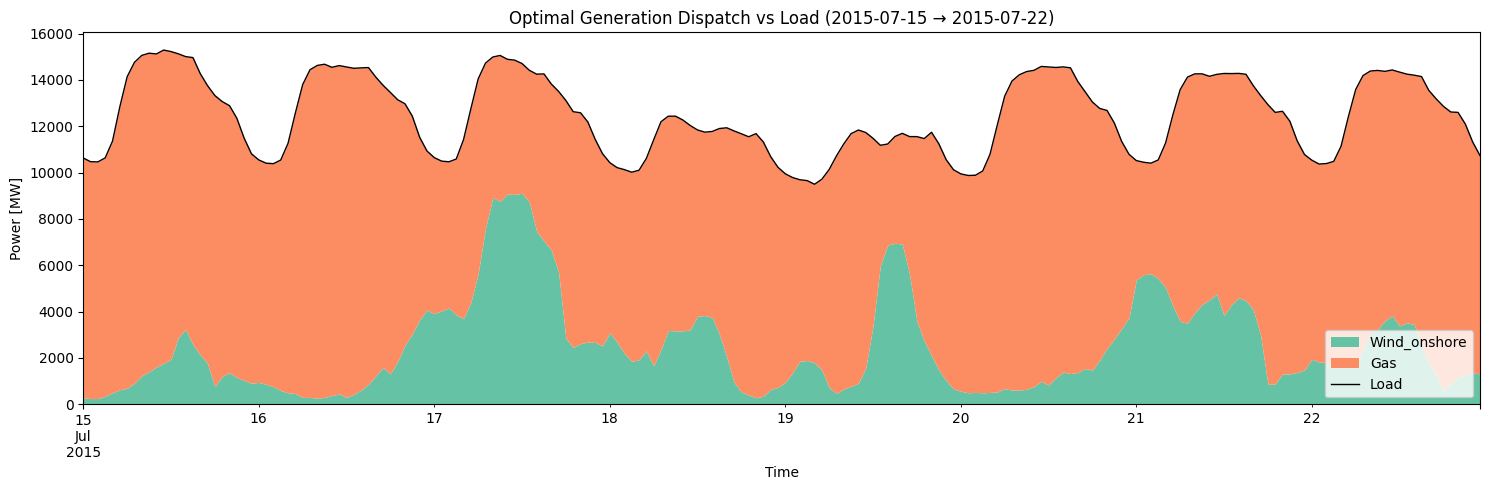

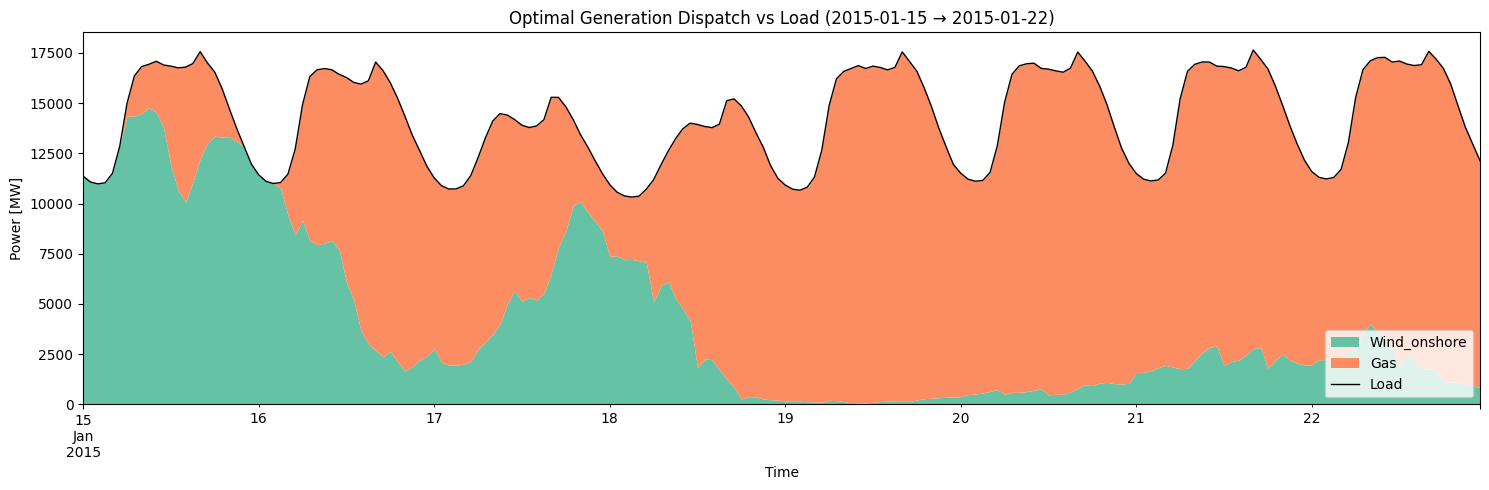

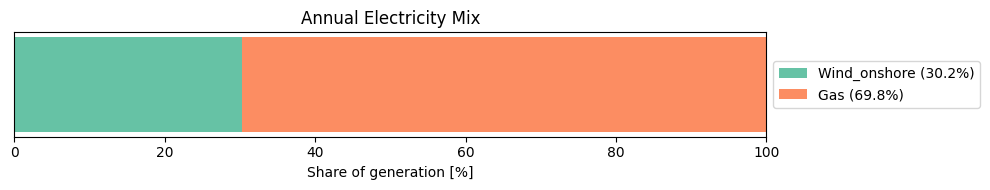

In [4]:
# Colors
carrier_colors = {
    "Wind_onshore": "#66c2a5",
    "Wind_offshore": "#3288bd",
    "Solar": "#ffd92f",
    "Gas": "#fc8d62",
    "Coal": "#4d4d4d",
}

# Define stack order: bottom → top
stack_order = ["Wind_onshore", "Wind_offshore", "Solar", "Coal", "Gas"]

# ---------------------
# SUMMER WEEK
# ---------------------

# --- Set start and end date for plotting ---
start_date = "2015-07-15"
end_date   = "2015-07-22"

# --- Apply mask ---
gen_dispatch = n.generators_t.p.loc[start_date:end_date]
load = n.loads_t.p_set.loc[start_date:end_date]

# --- Group by carrier ---
gen_dispatch_carrier = gen_dispatch.T.groupby(n.generators.carrier).sum().T

# --- Keep only carriers that actually generate power ---
gen_dispatch_carrier = gen_dispatch_carrier.loc[:, gen_dispatch_carrier.sum() > 0]

# --- Reorder columns to match stack order ---
gen_dispatch_carrier = gen_dispatch_carrier[[c for c in stack_order if c in gen_dispatch_carrier.columns]]

plt.figure(figsize=(15,5))

gen_dispatch_carrier.plot.area(
    ax=plt.gca(),
    linewidth=0,
    color=[carrier_colors[c] for c in gen_dispatch_carrier.columns]
)

(load.sum(axis=1)).plot(ax=plt.gca(), color='k', linewidth=1, label='Load')

plt.ylabel("Power [MW]")
plt.xlabel("Time")
plt.title(f"Optimal Generation Dispatch vs Load ({start_date} → {end_date})")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ---------------------
# WINTER WEEK
# ---------------------

# --- Set start and end date for plotting ---
start_date = "2015-01-15"
end_date   = "2015-01-22"

# --- Apply mask ---
gen_dispatch = n.generators_t.p.loc[start_date:end_date]
load = n.loads_t.p_set.loc[start_date:end_date]

# --- Group by carrier ---
gen_dispatch_carrier = gen_dispatch.T.groupby(n.generators.carrier).sum().T

# --- Keep only carriers that actually generate power ---
gen_dispatch_carrier = gen_dispatch_carrier.loc[:, gen_dispatch_carrier.sum() > 0]

# --- Reorder columns to match stack order ---
gen_dispatch_carrier = gen_dispatch_carrier[[c for c in stack_order if c in gen_dispatch_carrier.columns]]

plt.figure(figsize=(15,5))

gen_dispatch_carrier.plot.area(
    ax=plt.gca(),
    linewidth=0,
    color=[carrier_colors[c] for c in gen_dispatch_carrier.columns]
)

(load.sum(axis=1)).plot(ax=plt.gca(), color='k', linewidth=1, label='Load')

plt.ylabel("Power [MW]")
plt.xlabel("Time")
plt.title(f"Optimal Generation Dispatch vs Load ({start_date} → {end_date})")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ---------------------
# ANNUAL ELECTRICITY MIX
# ---------------------

# --- Slice generation ---
gen_dispatch = n.generators_t.p

# --- Aggregate by carrier ---
carrier_map = n.generators.carrier
gen_energy = gen_dispatch.sum().groupby(carrier_map).sum()

# --- Convert to percentage ---
gen_share = gen_energy / gen_energy.sum() * 100
gen_share = gen_share[gen_share > 1e-6]

# --- Keep order consistent with stack_order ---
gen_share = gen_share.reindex([c for c in stack_order if c in gen_share]).dropna()

# --- Plot ---
fig, ax = plt.subplots(figsize=(10,2))

left = 0
for carrier, value in gen_share.items():
    ax.barh(
        0,
        value,
        left=left,
        color=carrier_colors.get(carrier, "gray"),
        label=f"{carrier} ({value:.1f}%)"
    )
    left += value

ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel("Share of generation [%]")
ax.set_title(f"Annual Electricity Mix")

ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

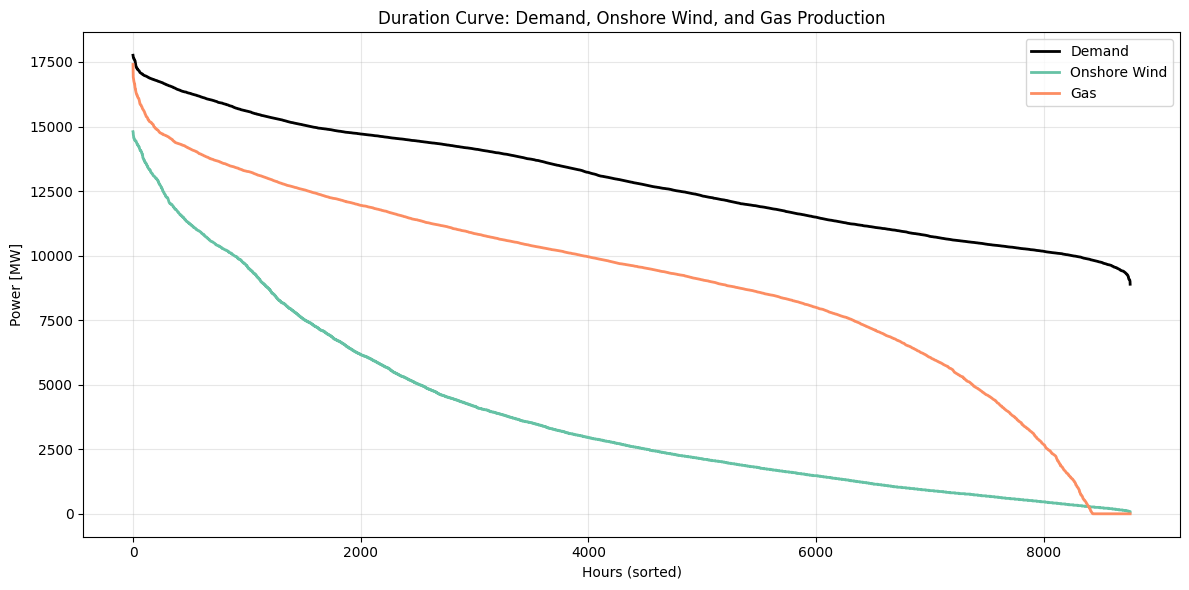

In [5]:
# ---------------------
# DURATION CURVE: Demand, Onshore Wind, Gas
# ---------------------

# --- Select time period (full year or a week) ---
start_date = "2015-01-01"
end_date   = "2015-12-31"

# --- Slice generation and load ---
gen_dispatch = n.generators_t.p.loc[start_date:end_date]
load = n.loads_t.p_set.loc[start_date:end_date]

# --- Aggregate by carrier ---
gen_dispatch_carrier = gen_dispatch.T.groupby(n.generators.carrier).sum().T

# --- Extract series ---
demand_series = load.sum(axis=1)
wind_onshore_series = gen_dispatch_carrier.get("Wind_onshore", pd.Series(0, index=demand_series.index))
gas_series = gen_dispatch_carrier.get("Gas", pd.Series(0, index=demand_series.index))

# --- Sort for duration curve (descending) ---
demand_sorted = demand_series.sort_values(ascending=False).reset_index(drop=True)
wind_sorted   = wind_onshore_series.sort_values(ascending=False).reset_index(drop=True)
gas_sorted    = gas_series.sort_values(ascending=False).reset_index(drop=True)

# --- Plot ---
plt.figure(figsize=(12,6))

plt.plot(demand_sorted, label="Demand", color="k", linewidth=2)
plt.plot(wind_sorted, label="Onshore Wind", color="#66c2a5", linewidth=2)
plt.plot(gas_sorted, label="Gas", color="#fc8d62", linewidth=2)

plt.xlabel("Hours (sorted)")
plt.ylabel("Power [MW]")
plt.title("Duration Curve: Demand, Onshore Wind, and Gas Production")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## b)

In [6]:
df_results = []

for year in CF_onshore.index.year.unique():
    
    # --- Update generator time series ---
    n.add(
        "Generator",
        "NLD onshore wind",
        bus="NLD",
        carrier="Wind_onshore",
        p_nom=0,
        marginal_cost=0,
        capital_cost=902000*annuity(0.07, 25),
        p_max_pu = CF_onshore["NLD"].loc[str(year)].values.ravel(),
        p_nom_extendable=True,
        overwrite=True,
    )
    
    n.add(
        "Generator",
        "NLD offshore wind",
        bus="NLD",
        carrier="Wind_offshore",
        p_nom=0,
        marginal_cost=0,
        capital_cost=2481000*annuity(0.07, 25),
        p_max_pu = CF_offshore["NLD"].loc[str(year)].values.ravel(),
        p_nom_extendable=True,
        overwrite=True,
    )
    
    n.add(
        "Generator",
        "NLD solar",
        bus="NLD",
        carrier="Solar",
        p_nom=0,
        marginal_cost=0,
        capital_cost=599000*annuity(0.07, 30),
        p_max_pu = CF_solar["NLD"].loc[str(year)].values.ravel(),
        p_nom_extendable=True,
        overwrite=True,
    )
    
    # --- Solve optimization ---
    n.optimize(solver_name="gurobi",
               solver_options={"LogToConsole": 0, "OutputFlag": 0})
    
    # --- Record results ---
    df_results.append({
        "year": year,
        "onshore_capacity": n.generators.p_nom_opt["NLD onshore wind"],
        "offshore_capacity": n.generators.p_nom_opt["NLD offshore wind"],
        "solar_capacity": n.generators.p_nom_opt["NLD solar"],
        "coal_capacity": n.generators.p_nom_opt["NLD coal"],
        "gas_capacity": n.generators.p_nom_opt["NLD gas"]
    })

# Convert to DataFrame
df_results = pd.DataFrame(df_results)

C:\Users\Victor Hald\AppData\Local\Temp\ipykernel_32304\646518019.py:46: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name="gurobi",
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 99.64it/s]

Set parameter Username
Set parameter LicenseID to value 2794235
Academic license - for non-commercial use only - expires 2027-03-18


Read LP format model from file C:\Users\Victor Hald\AppData\Local\Temp\linopy-problem-81pv_mf1.lp
Reading time = 0.23 seconds
obj: 96365 rows, 43805 columns, 170808 nonzeros
Set parameter LogToConsole to value 0


ValueError: setting an array element with a sequence.

## c)

In [ ]:
energy_cost = 110 # €/kWh
battery_hours = 4 # hours (change this to either 4, 6, or 8)
# PyPSA requires capital cost in €/kW, so we need to convert the energy cost to power cost
CAPEX_per_kW = energy_cost * battery_hours # €/kW

# This should be added to the PyPSA network
n.add("StorageUnit",
            name="battery",
            carrier="battery",
            bus="NLD",
            p_nom_extendable=True,
            max_hours=battery_hours,
            capital_cost=CAPEX_per_kW,
            marginal_cost=0,
            efficiency_store=0.95,
            efficiency_dispatch=0.95)